# CHURN ANALYSIS AND CUSTOMER INTELLIGENCE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3


# 1 Import Data

In [80]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """

SELECT name
FROM sqlite_master
WHERE type = 'table'

"""
tables = pd.read_sql(sql_query,conn)

# create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn) # Read table into dataframe
    globals()[f"df_{table_name}"] = df                    # Create dynamic dataframe name
    print(f"Created dataframe: df_{table_name}")

# Close connection
conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [81]:
# Print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


# 2 Data Cleaning

In [4]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [5]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [6]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [7]:
# Table 1 : df_db_customer

# a. rename - name to customer_name
# b. drop columns - interests and pincode
# c. dob - change str to datetime
# d. country - fill missing values
# e. Gender - Data Standaraliztion 


In [82]:
# a. rename - name to customer_name
df_db_customer.rename(columns = {'name': 'customer_name'}, inplace=True)

In [83]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     str   
 1   customer_name  21 non-null     str   
 2   country        18 non-null     str   
 3   state          21 non-null     str   
 4   gender         21 non-null     str   
 5   dob            21 non-null     str   
 6   interests      4 non-null      str   
 7   pincode        0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [84]:
# b. drop columns - interests and pincode
df_db_customer.drop(columns = ['interests', 'pincode'], inplace=True) # Columns based drop 

In [11]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerid     21 non-null     str  
 1   customer_name  21 non-null     str  
 2   country        18 non-null     str  
 3   state          21 non-null     str  
 4   gender         21 non-null     str  
 5   dob            21 non-null     str  
dtypes: str(6)
memory usage: 1.1 KB


In [85]:
# c. dob - change str to datetime
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [13]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        18 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.1 KB


In [86]:
# d. country - fill missing values

# df_db_customer[['country','state']].isna().sum()
df_db_customer[df_db_customer['country'].isna()]


,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [87]:
# country and state - unique value pair

# Creating state → country map from non-null rows
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

# Fill the missing country using State
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [88]:
# df_db_customer[['country','state']]
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        21 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.1 KB


In [17]:
# e. Gender - Data Standaraliztion 
df_db_customer['gender'].unique()

<StringArray>
['Male', 'Female', 'Women', 'Men']
Length: 4, dtype: str

In [89]:
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men': 'Male', 'Women':'Female'})

In [90]:
df_db_customer['gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

#### Table 2 : df_db_subscription

In [20]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [21]:
df_db_subscription.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
16,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,NaN,NaN,20.99,550,62
17,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,NaN,NaN,13.99,840,27
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,99
19,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,NaN,NaN,22.99,1955,7
20,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,NaN,NaN,13.99,790,47


In [22]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [23]:
# a. Date Format - subscription_start_date, renewal_date  and cancellation_date 
# b. Remove columns - cancellation_reason 

In [91]:
# a. Date Format - subscription_start_date, renewal_date  and cancellation_date 


date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [25]:
# b. Remove columns - cancellation_reason 

In [26]:
# df_db_subscription.drop(columns= ['cancellation_reason'], inplace=True)

In [27]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [28]:
# df_db_subscription[['cancellation_date']]

#### Table 3 : df_db_support

In [29]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [30]:
df_db_support.tail()

,customerid,complaint_date,escalations,csat_score,col_1,comment
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,None,NaN
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,None,NaN
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,None,NaN
8,0022-TCJCI,2024-09-14 00:00:00,N,90,None,received refund


In [31]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [32]:
# a. Convert str format to date format - complaint_date
# b. Drop garbage columns - col1 and comment

In [93]:
# a. Convert str format to date format - complaint_date
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [94]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
 4   col_1           0 non-null      object        
 5   comment         4 non-null      str           
dtypes: datetime64[us](1), int64(1), object(1), str(3)
memory usage: 564.0+ bytes


In [95]:
# b. Drop garbage columns - col1 and comment
df_db_support.drop(columns = ['col_1', 'comment'], inplace = True)

In [36]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


In [37]:
# df_db_support.head()
# df_db_support.tail()

# 3. Feature Engineering 

In [96]:
# create a new col using existing col - churn flag
# Customer is churned if cancellation_date is not null
# df_db_subscription.head()
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [39]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [97]:
# Fixed the support table because it has duplicate records
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [98]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep= 'last')

In [99]:
df_db_support['customerid'].size

7

In [78]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,1
8,0022-TCJCI,2024-09-14,N,90,1
6,0019-EFAEP,2024-09-27,Y,30,1


In [100]:
# Merge all tables using customer id 

df = (df_db_subscription
    .merge(df_db_customer, how='left', on='customerid')
    .merge(df_db_support, how = 'left', on = 'customerid'))



In [101]:
df.shape

(21, 21)

In [46]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0


In [102]:
df.to_csv('churn_analysis_cleaned.csv', index=False)

# 4. Data Analysis : 

In [48]:
df.columns


Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [103]:
# 1. Churn rate 
churn_rate = df['churn_flag'].mean()*100
print('churn_rate: ', round(churn_rate,2), '%')

churn_rate:  28.57 %


In [104]:
# 2. retention rate
retention_rate = 100 - churn_rate
print("Retention_rate: ", round(retention_rate,2),'%')

Retention_rate:  71.43 %


In [105]:
# 3. Churn by plan type
churn_plan_type = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_plan_type)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [52]:
# Our premium users churn are very less. It is good sign for our business. We have to find why our basic users churn most

In [53]:
# 4 a. Churn by state + sum(revenue) & count of users  -- home work **
# 4 b. Churn by subscription type + sum(revenue) & count of users   -- home work **

In [106]:
# df[['monthly_charges']]
# 4 a. Churn by state + sum(revenue) & count of users  
churn_by_state = (df.groupby('state')
                  .agg(churn_pct_by_state=('churn_flag', lambda x: round(x.mean()*100, 2)),
                       sum_of_revenue=('monthly_charges', 'sum'),
                      count_of_users = ('customerid','count'))
                  .reset_index())

print(churn_by_state)

           state  churn_pct_by_state  sum_of_revenue  count_of_users
0          Delhi               25.00           52.96               4
1      Karnataka              100.00           20.98               2
2      Kathmandu                0.00           20.98               2
3    Maharashtra                0.00           50.97               3
4      Meghalaya               66.67           42.97               3
5       Nagaland                0.00           22.99               1
6      Rajasthan                0.00           36.98               2
7      Telangana               50.00           30.98               2
8  Uttar Pradesh                0.00          115.98               2


In [55]:
# We need to work on why people of karnataka churn because 100 % churn from karnataka 

In [107]:
# 4 b. Churn by subscription type + sum(revenue) & count of users   -- home work **
churn_by_subscription = (df.groupby('subscription_type')
                         .agg(churn_pct_by_subs=('churn_flag', lambda x: round(x.mean()*100, 2)),
                              sum_of_revenue=('monthly_charges', 'sum'),
                              count_of_users=('customerid', 'count'))
                         .reset_index())

print(churn_by_subscription)

  subscription_type  churn_pct_by_subs  sum_of_revenue  count_of_users
0           Organic               0.00          145.91               9
1              Paid              16.67          174.94               6
2          Refferal              83.33           74.94               6


In [57]:
# Refferal users churn rates are very high 
# Organic users churn rate is 0 it is very good sign for our business

In [58]:
# 5. Average Revenue Per User (ARPU)
arpu = df['monthly_charges'].mean()
print("Average Revenue Per User:", round(arpu,2))

Average Revenue Per User: 18.85


In [108]:
# 6. Average customer tenure 
# count of days users has used our service : cancellation date else current date
today = pd.Timestamp.today()
# print(today)
df['tenure_days'] = np.where(
        df['cancellation_date'].notna(),

    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ", round(avg_tenure),0)

Avg Tenure (Days) =  1492 0


In [60]:
# homework - calculate customer age

In [109]:
# 7. Revenue at risk - revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk (Rs 'K') =", revenue_at_risk)

Revenue at Risk (Rs 'K') = 73.94


In [110]:
# 8. Esclation Rate
escalation_rate = (df['escalations']=='Y').mean()*100
print("Esclation Rate = ", round(escalation_rate, 2), "%")

Esclation Rate =  19.05 %


In [111]:
# 9. Avg Complaint Per User
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Compliants Per User = ", round(avg_complaints, 2))

Avg Compliants Per User =  0.43


In [112]:
# 10. Correlation Esclation vs Churn
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) # encoding string to int type
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between esclation vs churn is = ", round(correlation,2))

Correlation between esclation vs churn is =  0.77


In [113]:
# 11. Create a column using existing col - Churn risk
conditions = [
        (df['churn_score'] < 50),
        (df['churn_score'] >= 50) & (df['churn_score'] < 70),
        (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unkown')

In [114]:
df[['churn_risk','churn_score']].head()

,churn_risk,churn_score
0,low,12
1,high,91
2,low,34
3,low,8
4,high,88


In [115]:
df.shape

(21, 23)

# 5 Data Visualization

In [117]:
df_visual = df.copy()

In [116]:
df_visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1944.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1329.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2619.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high


In [69]:
df_visual.shape

(21, 23)

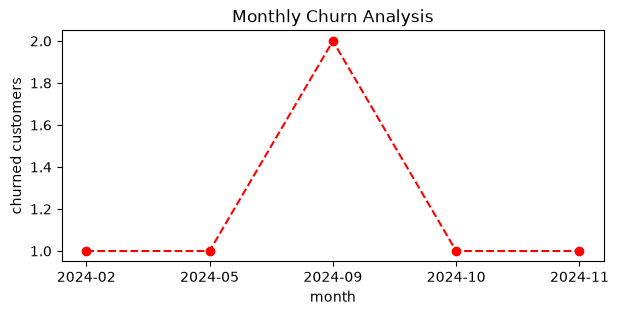

In [128]:
# 5.1 Monthly Churn Trend (Time Series KPI)
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')
# df_visual['cancellation_month']
churn_trend = df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()
# print(churn_trend)

plt.figure(figsize=(7,3))
plt.plot(churn_trend.index.astype('str'), churn_trend.values, color = 'red', marker = 'o', linestyle = 'dashed' )
plt.title('Monthly Churn Analysis')
plt.xlabel('month')
plt.ylabel('churned customers')
plt.show()


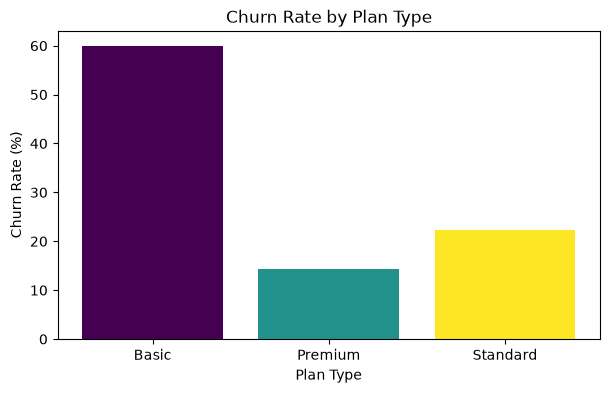

In [138]:
# 4.2 Churn Rate by Plan Type
churn_rate = (
    df_visual.groupby('plan_type')['churn_flag']
    .mean()
    .mul(100)
    .round(2)
)

colors = plt.cm.viridis(np.linspace(0, 1, len(churn_rate)))

plt.figure(figsize=(7, 4))
plt.bar(churn_rate.index, churn_rate.values, color=colors)

plt.title("Churn Rate by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Churn Rate (%)")

plt.show()

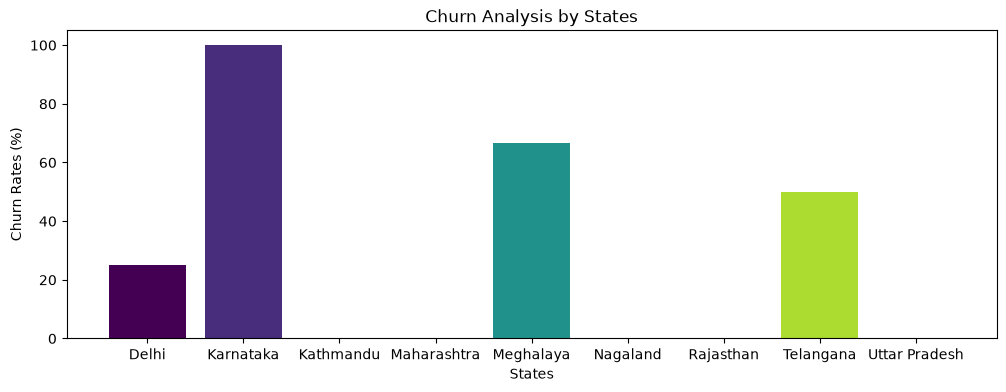

In [146]:
# 4.3 Churn by States
churn_by_state = df_visual.groupby('state')['churn_flag'].mean().mul(100).round(2)
# print(churn_by_state)
colors = plt.cm.viridis(np.linspace(0, 1, len(churn_by_state)))
plt.figure(figsize=(12, 4))
plt.bar(churn_by_state.index, churn_by_state.values, color = colors)
plt.title('Churn Analysis by States')
plt.xlabel('States')
plt.ylabel('Churn Rates (%)')
plt.show()

## Visualization using Seaborn

In [156]:
# remove warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Heatmap (Correlation Matrix)

###### encoding - convert str to numeric so that we can find corr between features


In [ ]:
print('plan_type :', df_visual['plan_type'].unique())
print('contract_type :', df_visual['contract_type'].unique())
print('churn_risk :', df_visual['churn_risk'].unique())

In [147]:
# Method of encoding - based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
    }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [148]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [149]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

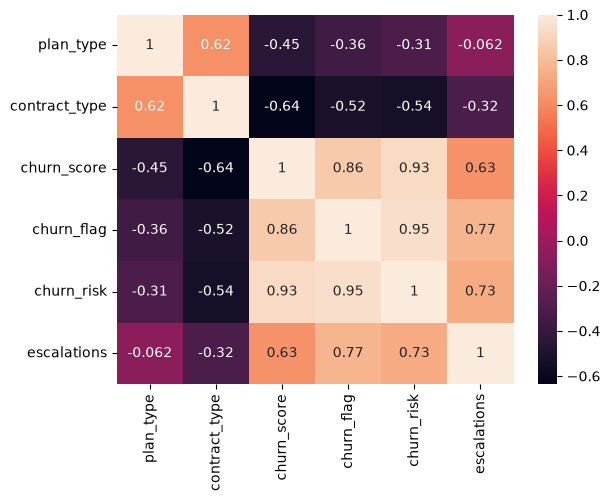

In [154]:
# heatmap(correlation matrix)
sns.heatmap(df_encoded.corr(), annot=True)


###### Heatmap Using Matplotlib - difficult to plot it


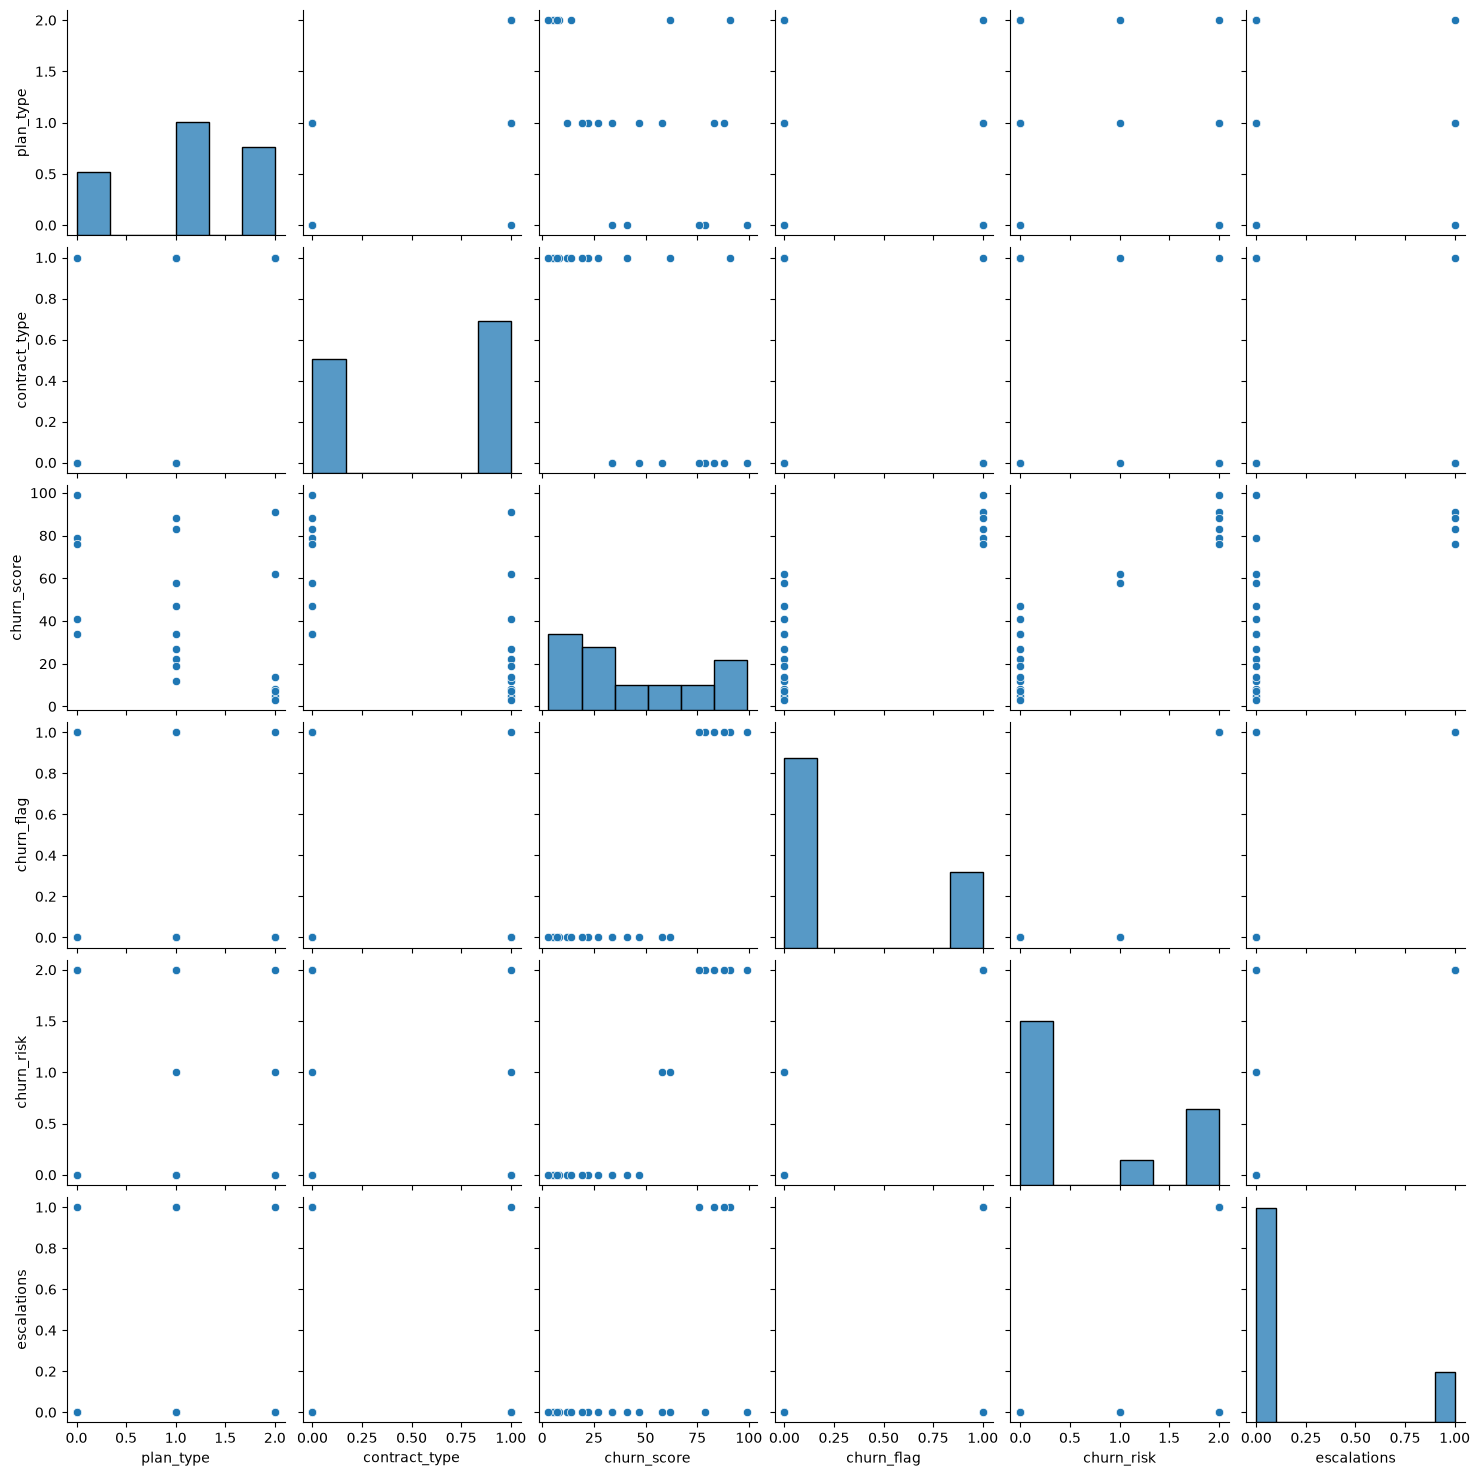

In [160]:
# pairplot - Plot pairwise relationships in a dataset
sns.pairplot(df_encoded)

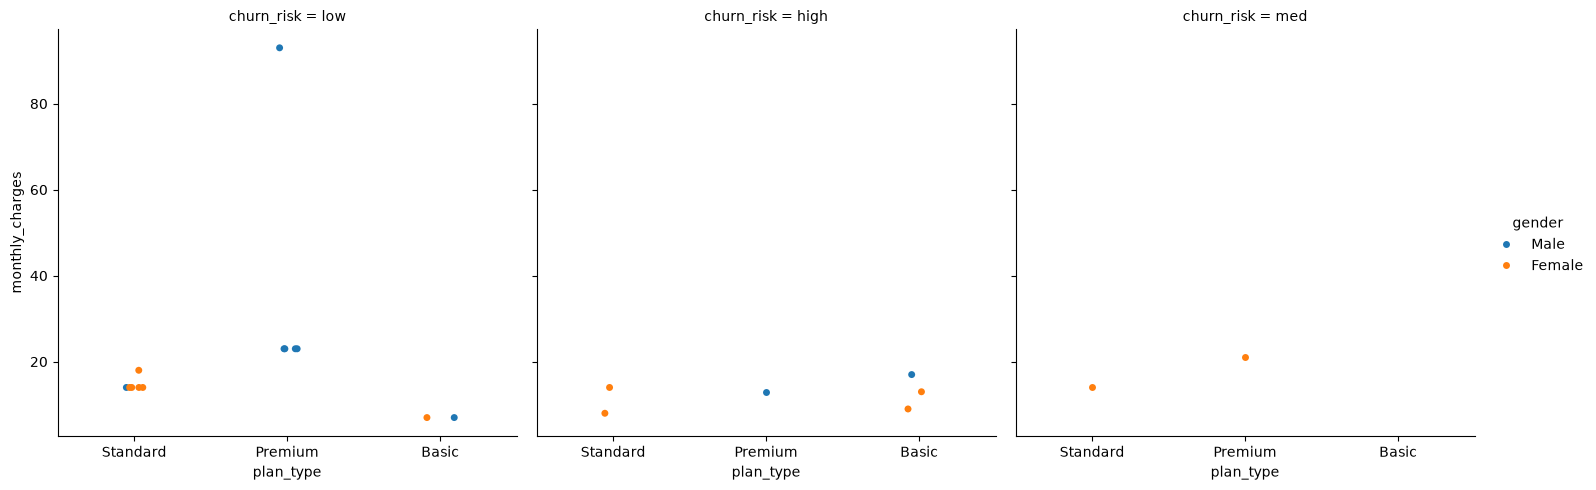

In [161]:
# catplt/Facegrid plot - multi-dim comparison

sns.catplot(data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk')

In [70]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='str')